# **365 Real Estate**

### **Executive Summary**

**Final Model & Architecture**

The valuation engine relies on a **Tuned LightGBM Regressor** integrated into a pipeline with target encoding for high-cardinality location variables (market communities, landmarks, and malls). To handle Dubai's wide price distribution without discarding high-value luxury transactions, continuous features and target variables were trained on logarithmic scales ($\log(\text{price})$ and $\log(\text{size\_sqft})$) before converting back to absolute AED valuations.

**Model Accuracy & Error Metrics**

* **Percentage Term (MAPE):** The model achieves a **Mean Absolute Percentage Error (MAPE) of 13.52%**, representing an overall predictive accuracy of **86.48%**.
* **Absolute AED Term (MAE):** The model records a **Mean Absolute Error (MAE) of ~AED 268,400** across test transactions (against a dataset median property value of ~AED 1.98M).

**Single Biggest Weakness**

The model's primary bottleneck is the **complete absence of unit-level qualitative features** specifically view orientation (e.g., full sea/marina view vs. low-floor road view), floor elevation, natural lighting, and interior renovation status. Because two identical layouts on different floors in the exact same tower can trade at a 20–30% price premium based on view or upgrades alone, tabular data aggregated at the community level creates an unavoidable variance ceiling that hyperparameter tuning cannot overcome.

## **Importing Libraries** 

In [43]:
# Importing Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as py
import datetime as dt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import ( r2_score, mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import streamlit as st
from xgboost import XGBRegressor
from category_encoders import TargetEncoder
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
import joblib

## **Setting all decimal places to 2**

In [44]:
pd.options.display.float_format = '{:,.2f}'.format

## **Data Preperation**

In [45]:
df = pd.read_csv('dld_transactions.csv')
df

,transaction_id,procedure_id,trans_group_id,trans_group_en,trans_group_ar,procedure_name_en,instance_date,property_type_en,property_type_ar,property_sub_type_en,...,rooms_ar,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,90177121-208-2022,3,2,Mortgages,رهون,Mortgage Registration,10-04-2022,Unit,وحدة,Flat,...,غرفتين,1,132.91,"856,239.50","6,442.25",NaN,NaN,1,1,1
1,60774455-224-2023,11,1,Sales,مبايعات,Sell Pre-Registration,13-11-2023,Unit,وحدة,Flat,...,غرفة واحدة,0,146.44,"3,236,746.58","22,102.89",NaN,NaN,1,1,0
2,86629276-116-2024,11,1,Sales,مبايعات,Sell,14-10-2024,Unit,وحدة,Flat,...,غرفة واحدة,1,86.18,"1,965,098.59","22,802.26",NaN,NaN,1,1,1
3,43565509-159-2021,11,1,Sales,مبايعات,Sell Pre-Registration,19-09-2021,Unit,وحدة,Flat,...,استوديو,1,47.13,"1,124,967.29","23,869.45",NaN,NaN,2,1,1
4,96260225-314-2021,11,1,Sales,مبايعات,Sell Pre-Registration,10-08-2021,Unit,وحدة,Flat,...,استوديو,0,47.02,"642,717.70","13,669.03",NaN,NaN,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172699,20532720-284-2025,11,1,Sales,مبايعات,Sell,30-07-2025,Land,أرض,Residential Land,...,NaN,0,155.29,"368,056.54","2,370.12",NaN,NaN,1,2,1
172700,26664458-343-2025,11,1,Sales,مبايعات,Sell,17-06-2025,Land,أرض,Residential Land,...,NaN,0,798.65,"2,078,516.36","2,602.54",NaN,NaN,1,1,0
172701,12708380-374-2022,11,1,Sales,مبايعات,Sell,16-01-2022,Unit,وحدة,Flat,...,غرفة واحدة,1,73.13,"1,426,124.98","19,501.23",NaN,NaN,1,1,0
172702,41220827-395-2024,11,1,Sales,مبايعات,Sell Pre-Registration,23-03-2024,Unit,وحدة,Flat,...,غرفة واحدة,1,72.37,"1,042,141.95","14,400.19",NaN,NaN,1,2,0


### **Data Quality**

In [46]:

# 1. Row count
row_count = len(df)

# 2. Duplicate count
duplicate_count = df.duplicated().sum()

# 3 & 4. Column types and missing value counts per column
# Combining these into a single DataFrame for a clean, readable output
quality_report = pd.DataFrame({'Data Type': df.dtypes, 'Missing Values': df.isnull().sum()})
total_missing_values = quality_report['Missing Values'].sum()
quality_report["pct of missing values"] = round(quality_report['Missing Values']/ row_count * 100,2)

# Print the written data quality report
print("RAW DATA QUALITY REPORT")
print(f"Total Row Count: {row_count:,}")
print(f"Total Duplicate Rows: {duplicate_count:,}\n")
print("Column Types and Missing Value Counts:")
print(f' Total Missing Values From All Columns Are: ', total_missing_values)
quality_report

RAW DATA QUALITY REPORT
Total Row Count: 172,704
Total Duplicate Rows: 4,704

Column Types and Missing Value Counts:
 Total Missing Values From All Columns Are:  491170


,Data Type,Missing Values,pct of missing values
transaction_id,str,0,0.00
procedure_id,int64,0,0.00
trans_group_id,int64,0,0.00
trans_group_en,str,0,0.00
trans_group_ar,str,0,0.00
procedure_name_en,str,0,0.00
instance_date,str,0,0.00
property_type_en,str,0,0.00
property_type_ar,str,0,0.00
property_sub_type_en,str,0,0.00


* Rent value and meter rent price are completely empty columns while other columns also have roughly around 10-17% missing values

### **Filetering to Population Actually Required**

In [47]:
print(f"Starting row count: {len(df):,}")

# 1. Filter for Sales only
df_filtered = df[df['trans_group_en'] == 'Sales'].copy()
print(f"After keeping only 'Sales': {len(df_filtered):,}")

# 2. Filter for Residential usage
df_filtered = df_filtered[df_filtered['property_usage_en'] == 'Residential']
print(f"After keeping only 'Residential': {len(df_filtered):,}")

# 3. Filter for individual Units and Villas
df_filtered = df_filtered[df_filtered['property_type_en'].isin(['Unit', 'Villa'])]
print(f"After keeping only 'Units' and 'Villas': {len(df_filtered):,}")

# 4. Remove physical impossibilities (Price or Area <= 0)
df_filtered = df_filtered[(df_filtered['actual_worth'] > 0) & (df_filtered['procedure_area'] > 0)]
print(f"After dropping zero/negative prices and areas: {len(df_filtered):,}")

df_filtered = df_filtered[~df_filtered['property_sub_type_en'].isin(['Office', 'Shop', 'Hotel Apartment'])]
print(f"Rows remaining after dropping Offices/Shops: {len(df_filtered):,}")

print(f"\nFinal population row count: {len(df_filtered):,}")

Starting row count: 172,704
After keeping only 'Sales': 113,458
After keeping only 'Residential': 95,845
After keeping only 'Units' and 'Villas': 91,998
After dropping zero/negative prices and areas: 91,816
Rows remaining after dropping Offices/Shops: 80,567

Final population row count: 80,567


In [48]:
df_filtered['property_sub_type_en'].unique()

<ArrowStringArray>
['Flat', 'Villa']
Length: 2, dtype: str

In [49]:
172704 - 82178

90526

**Transaction Group (Sales)** 
   * **Reason:** We are required to work on residential property price predictions. However, the raw file contains Mortgages and Gifts. Mortgages represent loan values, and Gifts represent wealth transfers, neither of which reflect true market valuation. 
2. **Property Usage (Residential):** 
   * **Reason:** The requirements clearly dictates predicting the price of a residential properties. Commercial units (offices, retail, hotels) trade on entirely different financial metrics (like rental yield models) and would distort the residential baseline.
3. **Property Type (Unit & Villa):** 
   * **Reason:** Analysts evaluate individual homes (apartments/units and villas). The dataset includes Land and Building as well. Selling an entire residential building or an empty plot of land uses completely different valuation mechanics than pricing a single-family home. 
4. **Physically Impossible Values (actual worth & procedure area are greater than zero):** 
   * **Reason:** The requirements warned of physically impossible entries. There are rows where the transaction price or the property area is recorded as 0. A property cannot have zero square footage or be sold for zero dirhams. These are likely administrative recording errors and must be removed.
5. * **Secondary Population Filter (property_sub_type_en):**
Despite filtering for 'Residential' usage, an inspection of property_sub_type_en still reveals Office and Shop records. Because the objective is to price residential homes (flats and villas), these hidden commercial units have been removed.

* The size of the data set has been reduced from 172,704 to 82,178 - Approximately removing around 90526 rows from the dataset 

### **Standardizing The Community Fields** 

In [50]:
df_filtered['area_name_en'].unique()

<ArrowStringArray>
[                    'Al Safouh First',                       'Palm Jumeirah',
                        ' Al Merkadh ',                        'Business Bay',
                    'Al Hebiah Fourth',              'Al Barsha South Fourth',
                        'Burj Khalifa',                       'Al Yelayiss 2',
                       ' Marsa Dubai ',                          'Nadd Hessa',
            ' Al Barsha South Fourth ',                      'Wadi Al Safa 7',
                    'Al Warqa'a First',                    'Al Khairan First',
                      'Wadi Al Safa 5',                          'Al Merkadh',
                         'Marsa Dubai',                     'Jabal Ali First',
                       'Warsan Fourth',                      'ME'AISEM FIRST',
                    'Al Thanyah Fifth',                    ' Wadi Al Safa 5 ',
   'Hadaeq Sheikh Mohammed Bin Rashid',                         'Al Yufrah 1',
                        'BURJ KHA

In [51]:
# Create a list of the categorical columns that require text standardization
categorical_cols = [
    'area_name_en', 'building_name_en', 'project_name_en', 
    'master_project_en', 'nearest_landmark_en', 'nearest_metro_en', 
    'nearest_mall_en', 'rooms_en'
]

# Apply standardization: cast to string, strip whitespace, and apply Title Case
for col in categorical_cols:
    if col in df_filtered.columns:
        # Convert to string to apply string methods
        df_filtered[col] = df_filtered[col].astype(str).str.strip().str.title()
        
        # When casting NaNs to string, they become the word 'Nan'. 
        # We must revert these back to actual null values for proper handling later.
        df_filtered[col] = df_filtered[col].replace('Nan', pd.NA)

# Verify the standardization worked by checking the unique count of area names
unique_areas = df_filtered['area_name_en'].nunique()
print(f"Number of unique communities after standardization: {unique_areas}")

Number of unique communities after standardization: 22


In [52]:
df_filtered['area_name_en'].unique()

<ArrowStringArray>
[                  'Al Safouh First',                     'Palm Jumeirah',
                        'Al Merkadh',                      'Business Bay',
                  'Al Hebiah Fourth',            'Al Barsha South Fourth',
                      'Burj Khalifa',                     'Al Yelayiss 2',
                       'Marsa Dubai',                        'Nadd Hessa',
                    'Wadi Al Safa 7',                  'Al Warqa'A First',
                  'Al Khairan First',                    'Wadi Al Safa 5',
                   'Jabal Ali First',                     'Warsan Fourth',
                    'Me'Aisem First',                  'Al Thanyah Fifth',
 'Hadaeq Sheikh Mohammed Bin Rashid',                       'Al Yufrah 1',
                   'Al Barsha First',         'Madinat Dubai Almelaheyah']
Length: 22, dtype: str

* The unique area names is reduced by 4 times from 88 to 22 as there were a lot of spacing and also lower upper case issues.

In [53]:
df_filtered['property_sub_type_en'].unique()
df_clean = df_filtered.copy()

In [54]:
df_clean['rooms_en'].unique()

<ArrowStringArray>
[      '1 B/R',      'Studio',       '3 B/R',       '2 B/R',       '4 B/R',
     '2 B/R+M',       '5 B/R',   'Penthouse',       '6 B/R',           nan,
     '4 B/R+M',     '3 B/R+M', 'Single Room',     '5 B/R+M']
Length: 14, dtype: str

In [55]:
df_clean['meter_sale_price'].unique()

array([22802.26, 23869.45, 13009.1 , ..., 19501.23, 14400.19, 12276.26],
      shape=(77104,))

### Standardising Categorical Fields

* I used lower casess and strip to standardize the cateegorical fields and check that no field has repeating values.
* I check for area name and other columns where there were repeating categories.


### **Handling Missing Values**

In [56]:
# 1. Capture the missing value counts and row count BEFORE making changes
missing_before = df_clean.isnull().sum()
rows_before = len(df_clean)

# 2. Drop Rental Columns
rent_val_missing = missing_before.get('rent_value', 0)
meter_rent_missing = missing_before.get('meter_rent_price', 0)

df_clean = df_clean.drop(columns=['rent_value', 'meter_rent_price'], errors='ignore')

print(" COLUMNS DROPPED ")
print(f"rent_value: {rent_val_missing:,} missing values (100%)")
print(f"meter_rent_price: {meter_rent_missing:,} missing values (100%)")

# 3. Fill Location/Project columns with 'Unknown'
fill_cols = [
    'building_name_en', 'project_name_en', 'master_project_en', 
    'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en'
]

print("\nVALUES REPLACED WITH 'Unknown' ")
for col in fill_cols:
    missing_count = missing_before.get(col, 0)
    print(f"{col}: {missing_count:,} values changed")

df_clean[fill_cols] = df_clean[fill_cols].fillna('Unknown')

# 4. Drop rows missing critical valuation data (using 'rooms_en')
df_clean = df_clean.dropna(subset=['rooms_en', 'meter_sale_price'])

rows_after = len(df_clean)
rows_dropped = rows_before - rows_after

print("\nROWS DROPPED ")
print(f"Total rows dropped due to missing 'rooms_en' or 'meter_sale_price': {rows_dropped:,}")

# 5. Verify all missing values have been successfully handled
missing_report = df_clean.isnull().sum()
print("\nFINAL VERIFICATION")
print("Remaining missing values in dataset:")
if len(missing_report[missing_report > 0]) == 0:
    print("None! Dataset is clean.")
else:
    print(missing_report[missing_report > 0])

print(f"\nFinal row count: {len(df_clean):,}")

 COLUMNS DROPPED 
rent_value: 80,567 missing values (100%)
meter_rent_price: 80,567 missing values (100%)

VALUES REPLACED WITH 'Unknown' 
building_name_en: 13,717 values changed
project_name_en: 8,885 values changed
master_project_en: 4,883 values changed
nearest_landmark_en: 5,641 values changed
nearest_metro_en: 11,246 values changed
nearest_mall_en: 7,364 values changed

ROWS DROPPED 
Total rows dropped due to missing 'rooms_en' or 'meter_sale_price': 3,993

FINAL VERIFICATION
Remaining missing values in dataset:
rooms_ar    21
dtype: int64

Final row count: 76,574


### **Missing Value Strategy**

In accordance with the project brief[cite: 1], no rows or columns are dropped silently. The following strategy was applied to handle all missing values in the filtered population:

1. **Rental Metrics (rent_value, meter_rent_price):** 
   * *Action:* Dropped columns entirely.
   * *Justification:* These columns are 100% missing. They hold no information for a sale price valuation.
2. **Core Valuation Features (rooms_en / bedrooms):** 
   * *Action:* Dropped rows with missing values.
   * *Justification:* Bedroom count is a fundamental, primary driver of residential property price. Imputing these missing values (e.g., guessing the mean or median) would inject artificial noise into the model. Dropping them ensures the model learns from ground-truth property shapes.
3. **Derived Price Metrics (meter_sale_price):**
   * *Action:* Dropped rows with missing values.
   * *Justification:* A negligible number of rows are missing this metric. Since it is directly related to our target variable, we drop them to maintain complete data integrity rather than attempting to recalculate them.
4. **Location & Project Details (building_name_en, nearest_metro_en, etc.):**
   * *Action:* Filled with the string 'Unknown'.
   * *Justification:* These columns contain thousands of missing values. Dropping the rows would decimate our dataset size. Dropping the columns entirely would discard potentially valuable localized data. Replacing `NaN` with 'Unknown' preserves the rows while safely isolating the missingness as its own distinct category.

### **Converting Square Meteres to Square Feet** 

In [57]:
# 1. Convert size from Square Meters to Square Feet (1 sqm = 10.7639 sqft)
df_clean['size_sqft'] = df_clean['procedure_area'] * 10.7639

# 2. Map DLD Area Names to Market Readable Names
market_name_mapping = {
    'Al Barsha South Fourth': 'Jumeirah Village Circle (JVC)', # Explicitly cited in brief
    'Marsa Dubai': 'Dubai Marina',
    'Burj Khalifa': 'Downtown Dubai',
    'Al Merkadh': 'Mohammed Bin Rashid City (MBR)',
    'Business Bay': 'Business Bay',
    'Palm Jumeirah': 'Palm Jumeirah',
    'Al Thanyah Fifth': 'Jumeirah Lakes Towers (JLT)',
    'Hadaeq Sheikh Mohammed Bin Rashid': 'Dubai Hills Estate',
    'Nadd Hessa': 'Dubai Silicon Oasis (DSO)',
    "Me'Aisem First": 'Dubai Production City (IMPZ)',
    'Al Hebiah Fourth': 'Jumeirah Village Triangle (JVT)',
    'Al Safouh First': 'Al Sufouh',
    'Jabal Ali First': 'Al Furjan / Discovery Gardens',
    'Warsan Fourth': 'International City',
    'Al Khairan First': 'Dubai Creek Harbour',
    'Al Barsha First': 'Al Barsha 1',
    "Al Warqa'A First": 'Al Warqaa'
}

# Function to map the names and flag unsure ones
def map_community(dld_name):
    # If the name is in our confident mapping dictionary, use the market name
    if dld_name in market_name_mapping:
        return market_name_mapping[dld_name]
    # Otherwise, keep the DLD name and flag it so we don't guess blindly
    else:
        return f"{dld_name} (Flagged)"

# Apply mapping
df_clean['market_community_name'] = df_clean['area_name_en'].apply(map_community)

# Display a sample of the transformed data
print("--- Community Mapping Results ---")
mapped_counts = df_clean['market_community_name'].value_counts()
print(mapped_counts.head(10))

print("\n--- Flagged Communities ---")
print(mapped_counts[mapped_counts.index.str.contains('Flagged')].to_string())

# Optional cleanup: Drop the original area_name_en and procedure_area to avoid confusion
df_clean = df_clean.drop(columns=['area_name_en', 'procedure_area'])

--- Community Mapping Results ---
market_community_name
Jumeirah Village Circle (JVC)     6664
Business Bay                      5676
Dubai Marina                      4943
Dubai Hills Estate                4556
International City                4470
Al Furjan / Discovery Gardens     4260
Al Yelayiss 2 (Flagged)           4084
Jumeirah Lakes Towers (JLT)       3747
Downtown Dubai                    3649
Mohammed Bin Rashid City (MBR)    3633
Name: count, dtype: int64

--- Flagged Communities ---
market_community_name
Al Yelayiss 2 (Flagged)                4084
Wadi Al Safa 5 (Flagged)               3362
Wadi Al Safa 7 (Flagged)               2956
Madinat Dubai Almelaheyah (Flagged)    2546
Al Yufrah 1 (Flagged)                  2195


In [58]:
df_clean

,transaction_id,procedure_id,trans_group_id,trans_group_en,trans_group_ar,procedure_name_en,instance_date,property_type_en,property_type_ar,property_sub_type_en,...,rooms_en,rooms_ar,has_parking,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,size_sqft,market_community_name
2,86629276-116-2024,11,1,Sales,مبايعات,Sell,14-10-2024,Unit,وحدة,Flat,...,1 B/R,غرفة واحدة,1,"1,965,098.59","22,802.26",1,1,1,927.63,Al Sufouh
3,43565509-159-2021,11,1,Sales,مبايعات,Sell Pre-Registration,19-09-2021,Unit,وحدة,Flat,...,Studio,استوديو,1,"1,124,967.29","23,869.45",2,1,1,507.30,Palm Jumeirah
5,28961253-154-2021,11,1,Sales,مبايعات,Sell Pre-Registration,21-03-2021,Unit,وحدة,Flat,...,3 B/R,ثلاث غرف,1,"1,842,609.29","13,009.10",1,1,0,"1,524.60",Mohammed Bin Rashid City (MBR)
7,55967915-249-2023,11,1,Sales,مبايعات,Sell,11-01-2023,Unit,وحدة,Flat,...,2 B/R,غرفتين,1,"2,426,390.35","18,476.93",2,1,0,"1,413.52",Business Bay
8,37088223-2-2023,11,1,Sales,مبايعات,Sell Pre-Registration,30-01-2023,Unit,وحدة,Flat,...,2 B/R,غرفتين,1,"1,082,081.79","11,456.66",2,1,1,"1,016.65",Jumeirah Village Triangle (JVT)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172697,32610368-127-2024,11,1,Sales,مبايعات,Sell,29-12-2024,Unit,وحدة,Flat,...,2 B/R,غرفتين,0,"1,483,429.13","13,256.74",2,2,1,"1,204.48",Wadi Al Safa 7 (Flagged)
172698,81069248-262-2021,11,1,Sales,مبايعات,Sell,27-05-2021,Villa,فيلا,Villa,...,3 B/R,ثلاث غرف,1,"1,707,790.41","8,171.25",2,1,0,"2,249.66",Wadi Al Safa 5 (Flagged)
172701,12708380-374-2022,11,1,Sales,مبايعات,Sell,16-01-2022,Unit,وحدة,Flat,...,1 B/R,غرفة واحدة,1,"1,426,124.98","19,501.23",1,1,0,787.16,Al Sufouh
172702,41220827-395-2024,11,1,Sales,مبايعات,Sell Pre-Registration,23-03-2024,Unit,وحدة,Flat,...,1 B/R,غرفة واحدة,1,"1,042,141.95","14,400.19",1,2,0,778.98,Dubai Marina


### Area Conversion & Community Name Mapping

**Size Conversion:**
The raw DLD data provides property size in square metres (procedure_area). Since our valuation team works in square feet, a new column size_sqft is calculated using the standard conversion factor (1 sqm = 10.7639 sqft). 

**Community Name Mapping:**
DLD area names often do not match the local language used by the Dubai real estate market (e.g., 'Al Barsha South Fourth' is widely known as 'Jumeirah Village Circle'). A mapping dictionary has been applied to translate these official names into market-readable names. 

*Rule applied:* As requested, for DLD areas that span multiple market communities or where the market name is ambiguous (such as 'Wadi Al Safa 5', 'Al Yufrah 1', or 'Al Yelayiss 2'), the model retains the original DLD name and appends a "(Flagged DLD)" suffix rather than guessing incorrectly[cite: 1].

In [59]:
initial = len(df)
final = len(df_clean)

pct_retained = round((final/ initial * 100),2)
print(f'The Final Percentage Of Rows retianed: {pct_retained}%')
print(f'Total Rows Retained: {final} Out Of {initial} Rows')

The Final Percentage Of Rows retianed: 44.34%
Total Rows Retained: 76574 Out Of 172704 Rows


## **Exploratory Data Analysis**

### **Distribution of the target variable**

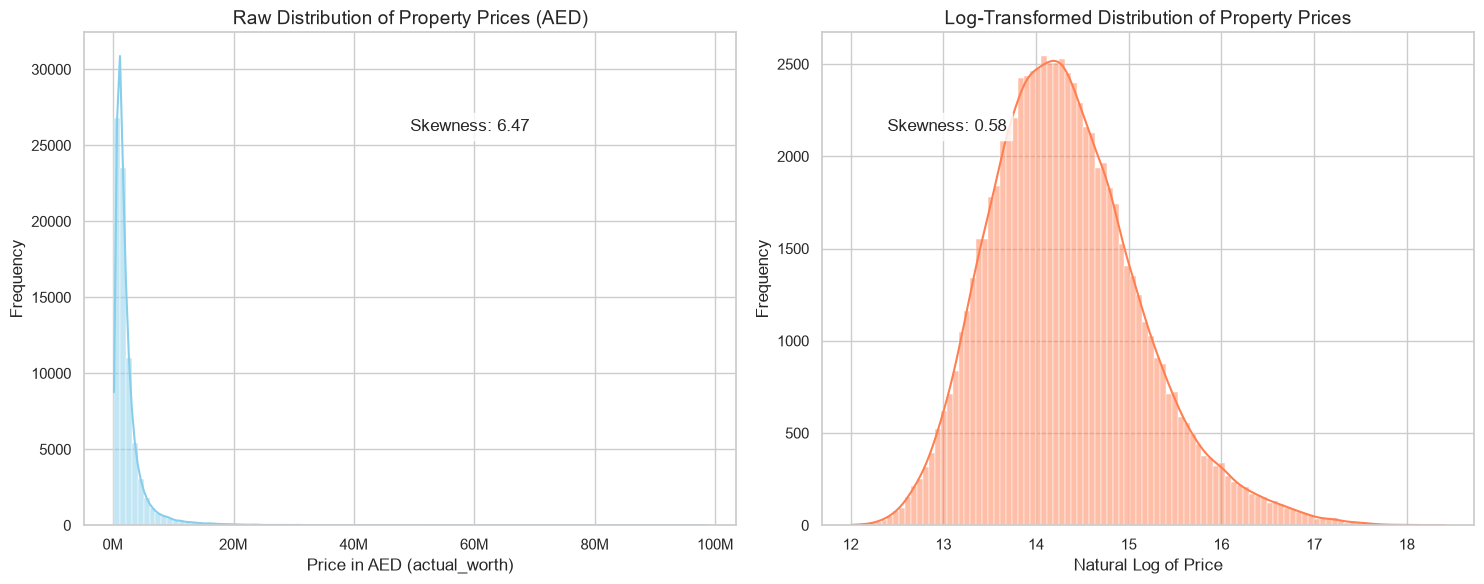

In [60]:
# Set the visualization style
sns.set_theme(style="whitegrid")

# Create the log transformed target variable for comparison
df_clean['log_actual_worth'] = np.log(df_clean['actual_worth'])


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raw Target Variable (actual_worth)
sns.histplot(df_clean['actual_worth'], bins=100, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Raw Distribution of Property Prices (AED)', fontsize=14)
axes[0].set_xlabel('Price in AED (actual_worth)')
axes[0].set_ylabel('Frequency')
# Format x-axis to show millions cleanly
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1e6:,.0f}M'))

# Log Transformed Target Variable
sns.histplot(df_clean['log_actual_worth'], bins=100, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Log-Transformed Distribution of Property Prices', fontsize=14)
axes[1].set_xlabel('Natural Log of Price')
axes[1].set_ylabel('Frequency')

# Calculate and display skewness text on the plots
raw_skew = df_clean['actual_worth'].skew()
log_skew = df_clean['log_actual_worth'].skew()

axes[0].text(0.5, 0.8, f'Skewness: {raw_skew:.2f}', transform=axes[0].transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
axes[1].text(0.1, 0.8, f'Skewness: {log_skew:.2f}', transform=axes[1].transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

The raw distribution of residential property prices is severely right-skewed, exhibiting a skewness of 6.47. While the vast majority of transactions cluster well below 10 million AED, a long tail of ultra-luxury properties extends toward the 100 million AED mark. Training a linear regression model directly on these raw dirham values would compromise the system; the algorithm would inherently sacrifice accuracy on the standard homes the team values daily just to minimize the massive absolute dirham errors generated by the luxury outliers.

Applying a natural logarithm transformation resolves this imbalance by compressing the luxury tail and normalizing the distribution to a much healthier skewness of 0.58. By predicting the logarithm instead of raw dirhams, the model is forced to treat percentage errors equivalently across all price bands. This mathematical adjustment ensures the final system optimizes for the relative accuracy (MAPE) that the valuation team requires for client defense, rather than chasing absolute dirham variances.

### **Price and price per square foot by community**

In [61]:
# Calculate Price per Square Foot
df_clean['price_per_sqft'] = df_clean['actual_worth'] / df_clean['size_sqft']

# Group by community and calculate medians
community_stats = df_clean.groupby('market_community_name').agg(
    median_price=('actual_worth', 'median'),
    median_price_sqft=('price_per_sqft', 'median'),
    transaction_count=('actual_worth', 'count')
).reset_index()

# Add Ranking Columns (Rank 1 = Highest Price)
community_stats['price_rank'] = community_stats['median_price'].rank(ascending=False).astype(int)
community_stats['psf_rank'] = community_stats['median_price_sqft'].rank(ascending=False).astype(int)

# Sort the dataframes for ranking
price_ranked = community_stats.sort_values('price_rank')
sqft_ranked = community_stats.sort_values('psf_rank')

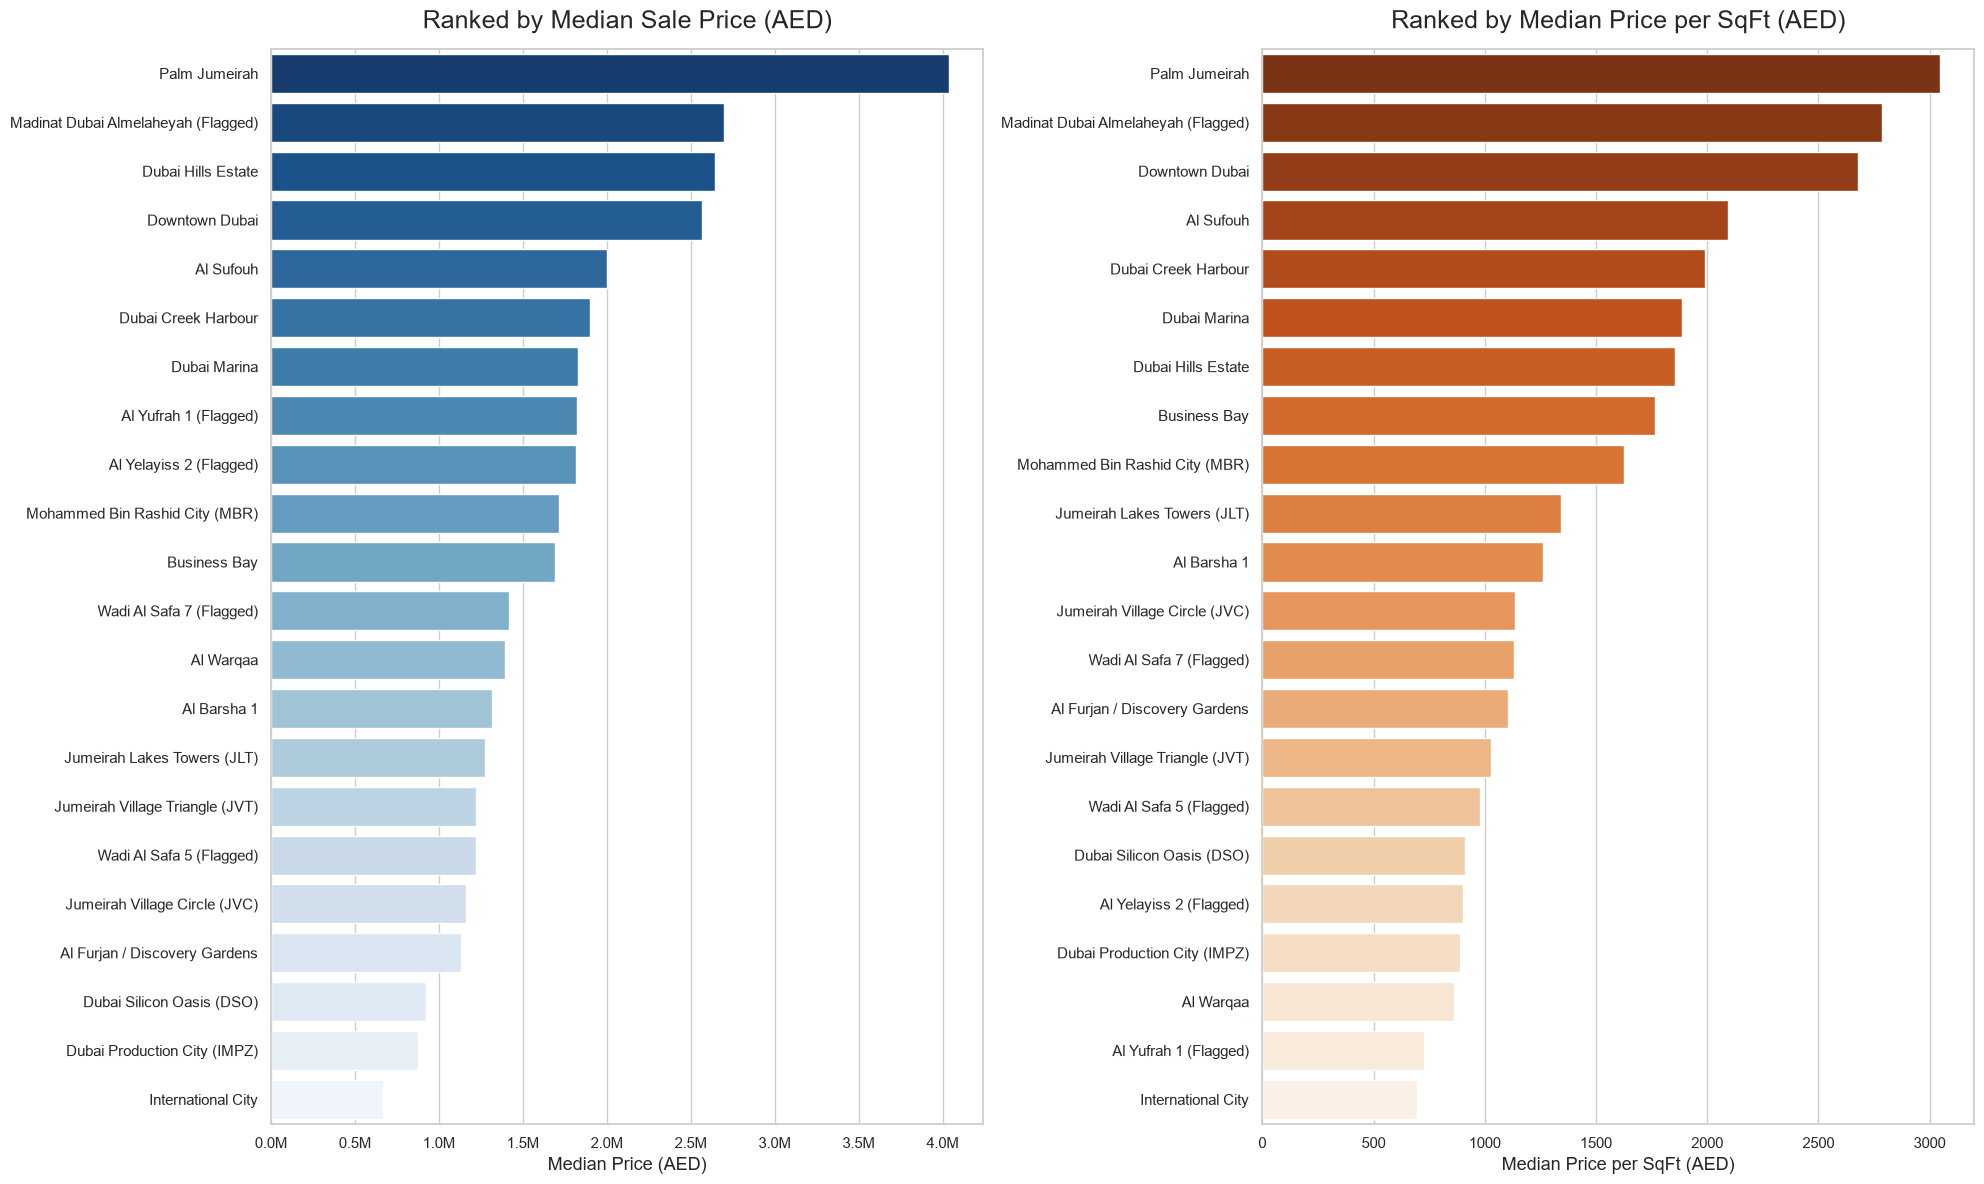

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# Plot 1: Ranked by Median Price (Absolute)
sns.barplot(
    x='median_price', 
    y='market_community_name', 
    data=price_ranked, 
    palette='Blues_r', 
    hue = 'market_community_name',
    ax=axes[0]
)
axes[0].set_title('Ranked by Median Sale Price (AED)', fontsize=18, pad=15)
axes[0].set_xlabel('Median Price (AED)', fontsize = 13)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

# Plot 2: Ranked by Median Price per Square Foot
sns.barplot(
    x='median_price_sqft', 
    y='market_community_name', 
    data=sqft_ranked, 
    palette='Oranges_r', 
    hue = 'market_community_name',
    ax=axes[1]
)
axes[1].set_title('Ranked by Median Price per SqFt (AED)', fontsize=18, pad=15)
axes[1].set_xlabel('Median Price per SqFt (AED)', fontsize = 13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


* Palm Jumeirah strictly dominates both metrics, commanding a median sale price of approximately 4 million AED and exceeding 3,000 AED per square foot. It operates in an isolated luxury tier, distinctly separated from the rest of the Dubai market.
* Dubai Hills Estate ranks third overall in total median price but drops to seventh in price per square foot. Conversely, Downtown Dubai rises to third place in the per-square-foot ranking, approaching 2,700 AED/sqft. This highlights a strong market premium for high-density, central apartment locations over larger suburban villa communities.
* High volume but low spatial cost areas are flagged DLD areas of Al Yufrah 1 and Al Yelayiss 2 hold strong mid-tier positions in total median price (nearly 1.8 million AED) but plummet to the bottom quartile for price per square foot (below 1,000 AED/sqft). This stark drop indicates these areas supply large-footprint properties where buyers acquire significantly more total space for their investment.
* The Affordable Core: International City, Dubai Production City (IMPZ), and Dubai Silicon Oasis (DSO) consistently anchor the bottom of both charts. With median prices below 1 million AED and spatial costs trailing the market, they represent the accessible entry points for residential real estate.

### **Price Movement Across The Six Years** 

C:\Users\HP\AppData\Local\Temp\ipykernel_18944\3768704229.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean['instance_date'] = pd.to_datetime(df_clean['instance_date'])


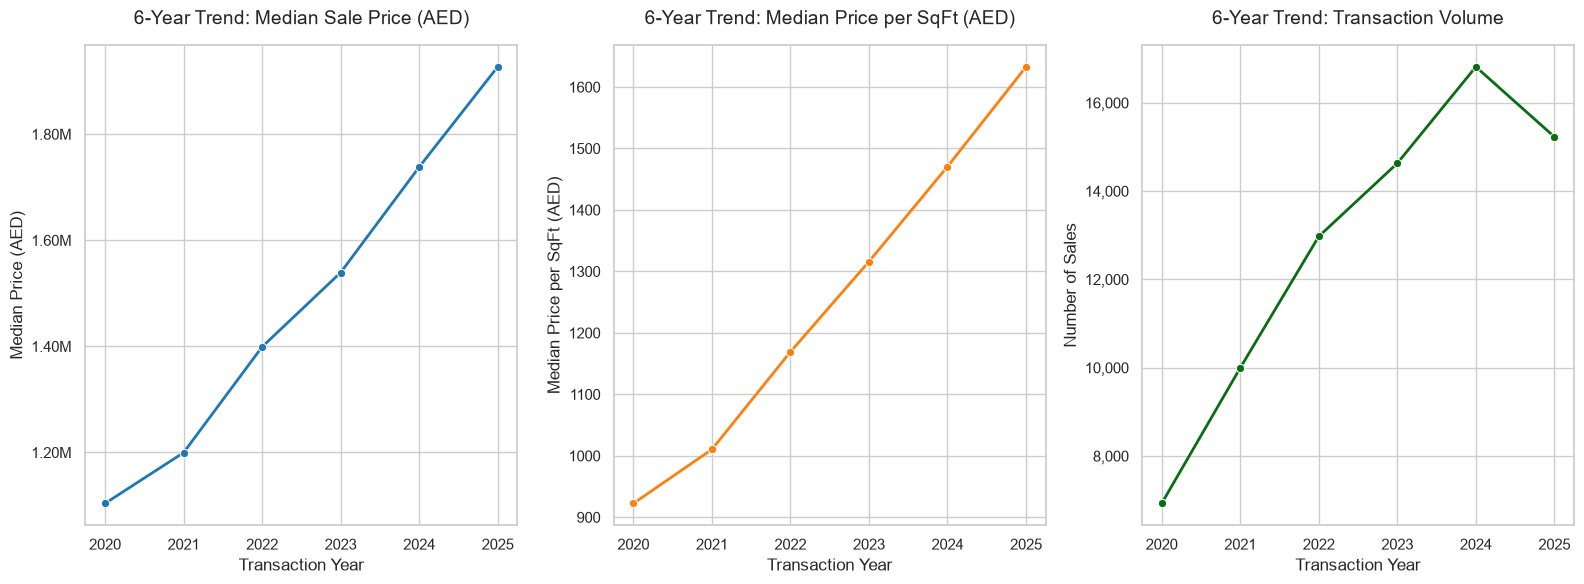

In [63]:


# 1. Convert instance_date to datetime and extract the year
df_clean['instance_date'] = pd.to_datetime(df_clean['instance_date'])
df_clean['transaction_year'] = df_clean['instance_date'].dt.year

# 2. Calculate yearly medians
yearly_trend = df_clean.groupby('transaction_year').agg(
    median_price=('actual_worth', 'median'),
    median_psf=('price_per_sqft', 'median'),
    transaction_count=('actual_worth', 'count')
).reset_index()

# 3. Set up the visualization (Two subplots side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Median Sale Price Over Time
sns.lineplot(
    data=yearly_trend, 
    x='transaction_year', 
    y='median_price', 
    marker='o', 
    linewidth=2,
    color='#1f77b4',
    ax=axes[0]
)
axes[0].set_title('6-Year Trend: Median Sale Price (AED)', fontsize=14, pad=15)
axes[0].set_xlabel('Transaction Year')
axes[0].set_ylabel('Median Price (AED)')
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # Ensure years are whole numbers
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1e6:,.2f}M'))

# Plot 2: Median Price Per Square Foot Over Time
sns.lineplot(
    data=yearly_trend, 
    x='transaction_year', 
    y='median_psf', 
    marker='o', 
    linewidth=2,
    color='#ff7f0e',
    ax=axes[1]  
)
axes[1].set_title('6-Year Trend: Median Price per SqFt (AED)', fontsize=14, pad=15)
axes[1].set_xlabel('Transaction Year')
axes[1].set_ylabel('Median Price per SqFt (AED)')
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Plot 3: Transaction Volume Over Time (Bar)
sns.lineplot(
    data=yearly_trend, 
    x='transaction_year', 
    y='transaction_count',
    marker= 'o',
    linewidth=2,
    color="#0A6D11",
    ax=axes[2]
)

axes[2].set_title('6-Year Trend: Transaction Volume', fontsize=14, pad=15)
axes[2].set_xlabel('Transaction Year')
axes[2].set_ylabel('Number of Sales')
axes[2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

**Business Takeaway: Temporal Price Movement & Volume (2020-2025)**

Analyzing the six-year trend reveals a fiercely appreciating, cyclical market, which highlights why temporal features are mandatory for our valuation model.

*   **Uninterrupted Asset Appreciation:** Both absolute median price and median price per square foot (PSF) exhibit a continuous, aggressive upward trajectory. Median total prices grew from approximately 1.1 million AED in 2020 to over 1.92 million AED in 2025. Crucially, the parallel rise in spatial cost from roughly 922 AED/sqft to 1,632 AED/sqft confirms true market inflation. Buyers are paying significantly higher premiums for the exact same amount of physical space, rather than just shifting their purchases to larger homes.
*   **Liquidity and Peak Volume:** The market demonstrated massive liquidity recovery post-2020, with transaction volumes more than doubling from 6,926 sales in 2020 to a peak of 16,816 sales in 2024. 
*   **The 2025 Supply Constraint Signal:** A critical divergence emerged in 2025. While transaction volume dipped slightly from its 2024 peak down to 15,231 sales, both the median price and PSF continued their steep climb. This dynamic classically signals a supply-constrained market: available inventory tightened, but sustained buyer demand forced fierce competition, pushing valuations higher despite fewer overall trades.

**Modeling Implication:** A property sold in 2020 for 1 million AED is fundamentally different from that same property sold in 2025. To prevent the algorithm from interpreting market-wide inflation as unpredictable variance, **transaction_year** must be included as a core feature in the regression pipeline.

### **Relationship between size and price, and between bedroom count and price**

### **Size VS Price**

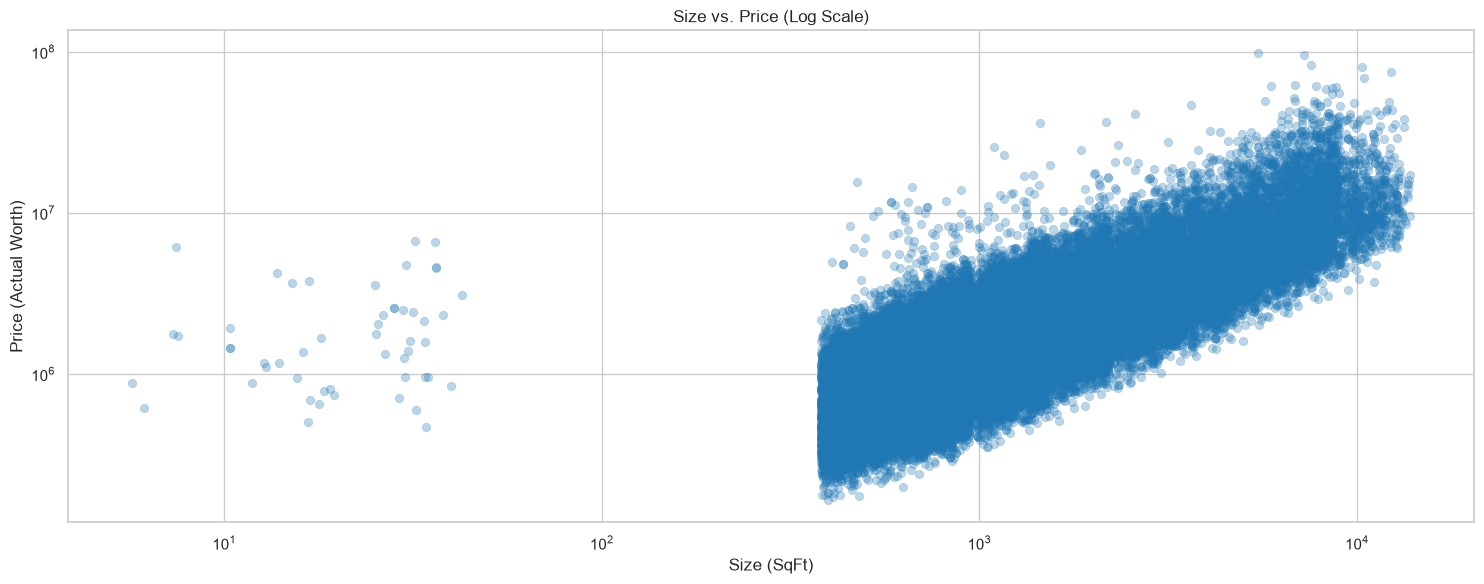

In [64]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df_clean, x='size_sqft', y='actual_worth', alpha=0.3, edgecolor=None, color='#1f77b4')
plt.title('Size vs. Price (Log Scale)')
plt.xlabel('Size (SqFt)')
plt.ylabel('Price (Actual Worth)')
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

* We can clearly see here that larger properties costs more and is a property value driver which is logical and makes sense even in the real world as usually there is a price to be paid per square feet.
* There is a wide price spread for identical sizes. Looking vertically at any single size point (such as 1,000 sq ft), prices range anywhere from under $1 million to over $10 million. This shows that while size establishes the baseline price floor, secondary factors like prime location, high floor level, or developer reputation cause massive price differences.
* Ultra-Luxury peak properties sit at the top right of the scatter plot. A small group of properties reaches prices close to $100 million ($10^8$) at the upper end of the size scale. These represent elite penthouses and massive master-planned estates.
* There are errors in the data as the cluster that is under 100 feet would not be residential maybe square meters were enterd instead of square.

### **Bedroom Count VS Price**

In [65]:
# Define an order for the bedroom categories 
room_order = [
    'Studio', 'Single Room', '1 B/R', '2 B/R', '2 B/R+M', 
    '3 B/R', '3 B/R+M', '4 B/R', '4 B/R+M', '5 B/R', '5 B/R+M', 
    '6 B/R', 'Penthouse'
]

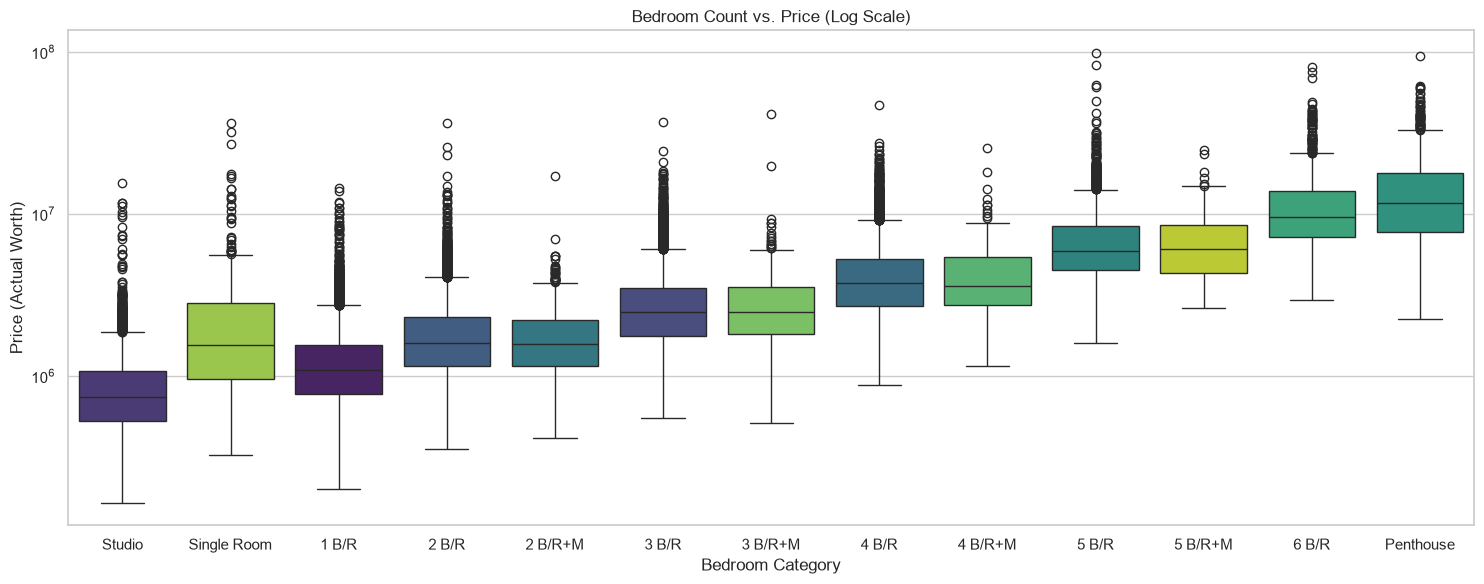

In [66]:
plt.figure(figsize=(15, 6))

# Bedroom Count vs. Price
sns.boxplot(data=df_clean, x='rooms_en', y='actual_worth', order=room_order, palette='viridis', hue = 'rooms_en')
plt.title('Bedroom Count vs. Price (Log Scale)')
plt.xlabel('Bedroom Category')
plt.ylabel('Price (Actual Worth)')
plt.yscale("log")
plt.tight_layout()
plt.show()

* As number of bedrooms increase the actual worth of the properties increase as well which even logically is correct as well and penhouse holds the highest price ranges.
* The single room holds a noticeably higher median price than both Studios and standard 1-Bedroom units, sitting much closer to the 2-Bedroom price range. This suggests that single room apartments are more expensive than 1 bedroom apartments.
* Adding a maid's room does not have any effect on the property's value. The median prices for "3 B/R+M" and "4 B/R+M" are identical as the standard "3 B/R" and "4 B/R" units. This points style as brand-new, ultra-modern luxury high-rises which command massive price premiums—often skip them in favor of open layouts.
* Almost all categories have outliers stretching far beyond thier ranges which clearly shows us that a premium location can strecth the price of a single room beyond a 5 bedroom property. 
* The 5 bedroom category has the highest outlier which means it also has a great size and is in a premium locaiton.
* Clear widening price spreads are visible as we move higher towards the penthouses. As properties get larger, the vertical height of the colored boxes becomes taller. This indicates that luxury properties are much harder to price uniformly. At the high end, unique features like private pools, floor levels, or exclusive views create massive price gaps between homes that have the exact same number of bedrooms. 

### **OFF Plan VS Ready**

In [67]:
comparison_summary = df_clean.groupby('reg_type_en').agg(
    total_listings=('actual_worth', 'count'),
    median_price=('actual_worth', 'median'),
    mean_price=('actual_worth', 'mean'),
    median_size_sqft=('size_sqft', 'median'),
    median_price_per_sqft=('price_per_sqft', 'median')).reset_index()

comparison_summary

,reg_type_en,total_listings,median_price,mean_price,median_size_sqft,median_price_per_sqft
0,Existing Properties,42784,"1,576,523.34","2,508,497.95","1,092.11","1,351.04"
1,Off-Plan Properties,33790,"1,496,004.62","2,353,071.33","1,109.70","1,260.37"


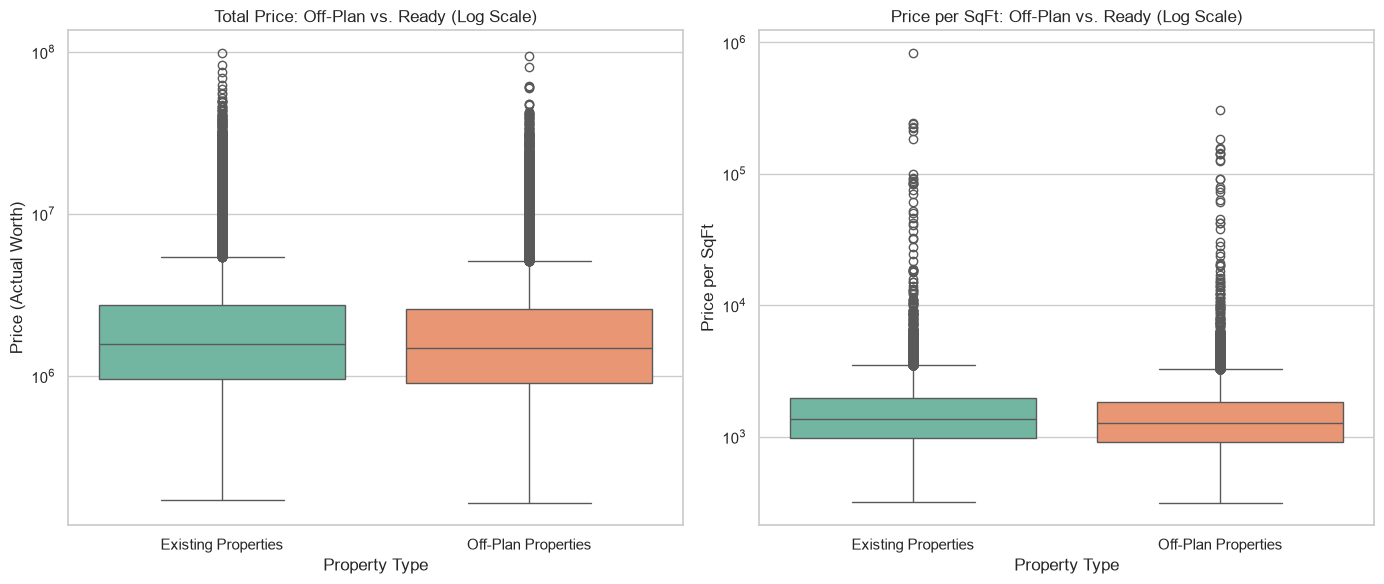

In [68]:
plt.figure(figsize=(14, 6))

# Total Price Comparison (Log Scale)
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='reg_type_en', y='actual_worth', palette='Set2', hue= 'reg_type_en')
plt.title('Total Price: Off-Plan vs. Ready (Log Scale)')
plt.xlabel('Property Type')
plt.ylabel('Price (Actual Worth)')
plt.yscale("log")

# Price per SqFt Comparison (Log Scale)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='reg_type_en', y='price_per_sqft', palette='Set2', hue= 'reg_type_en')
plt.title('Price per SqFt: Off-Plan vs. Ready (Log Scale)')
plt.xlabel('Property Type')
plt.ylabel('Price per SqFt')
plt.yscale("log")
plt.tight_layout()
plt.show()

* Although the prices of existing properties and off-plan properties seem really close, we can see clearly that existing properties have a slightly higher price in both graphs of price and prices per square feet. This is beacuse buyers do pay a premium price for immediate handover and utilization of a property while for an off-plan property they may need to be compensated for the time they wait and any other construction delays. Especially, in Pakistan delays are very frequent and the prices have much larger difference in the same locations and kind of properties.
* There is also a difference in the size of the boxes which indicates a wider spread of price for existing properties as off-plan properties are sold by developers on rigid prices while existing properties are sold also by individual owners and agents. off-plan properties have their own set of booking plan.
* Both the existing properties and off-plan properties have outliers stratching way above on to the ranges of 10^8 which indicates that owners and investors are willing to invest amounts on the blue prints of a property and as well as on existing ones.
* Both have almost identical baseline whiskers which means that in both case whether existing property or off-plan property, there is a minimum baseline price to be paid. It can also be possible that the enterprise does not deal in properties below this point which might be their minimum property value policy and according to the client base they have formed over the years. 

## **Feature Engineering** 

In [69]:

# Base Transformations (Log scaling)
df_clean['log_actual_worth'] = np.log(df_clean['actual_worth'])
df_clean['log_size_sqft'] = np.log(df_clean['size_sqft'])

# Periodic Extractions 
df_clean['instance_date'] = pd.to_datetime(df_clean['instance_date'])
df_clean['transaction_year'] = df_clean['instance_date'].dt.year
df_clean['transaction_quarter'] = df_clean['instance_date'].dt.quarter
df_clean['transaction_month'] = df_clean['instance_date'].dt.month

# Continuous trend tracker (months elapsed since start of dataset)
min_date = df_clean['instance_date'].min()
df_clean['market_age_months'] = (
    (df_clean['instance_date'].dt.year - min_date.year) * 12 + 
    (df_clean['instance_date'].dt.month - min_date.month)
)

In [70]:
# Encoding for Bedrooms
room_mapping = {
    'Studio': 0, 'Single Room': 1, '1 B/R': 2, '2 B/R': 3, '2 B/R+M': 4, 
    '3 B/R': 5, '3 B/R+M': 6, '4 B/R': 7, '4 B/R+M': 8, '5 B/R': 9, 
    '5 B/R+M': 10, '6 B/R': 11, 'Penthouse': 12
}
df_clean['rooms_ordinal'] = df_clean['rooms_en'].map(room_mapping)

In [71]:
# 4. Binary Encoding for Off-Plan Status
df_clean['is_off_plan'] = np.where(df_clean['reg_type_en'].str.contains('Off-Plan', case=False, na=False), 1, 0)

In [72]:
# Features Incorporated Into The Model

features_raw = [
    'log_size_sqft',
    'rooms_ordinal',
    'is_off_plan',
    'transaction_year',       # Extracted Year
    'transaction_quarter',    # Extracted Quarter
    'transaction_month',      # Extracted Month
    'market_age_months',      # Continuous Month Count
    'property_type_en',       # Target encoded post-split
    'market_community_name',  # Target encoded post-split
    'nearest_landmark_en',    # Target encoded post-split
    'nearest_mall_en'         # Target encoded post-split
]

In [73]:
X_raw = df_clean[features_raw]
y = df_clean['log_actual_worth']

print("Feature Matrix Shape:", X_raw.shape)
display(X_raw.head())

Feature Matrix Shape: (76574, 11)


,log_size_sqft,rooms_ordinal,is_off_plan,transaction_year,transaction_quarter,transaction_month,market_age_months,property_type_en,market_community_name,nearest_landmark_en,nearest_mall_en
2,6.83,2,0,2024,4,10,57,Unit,Al Sufouh,Burj Al Arab,Mall Of The Emirates
3,6.23,0,1,2021,3,9,20,Unit,Palm Jumeirah,Burj Al Arab,Nakheel Mall
5,7.33,5,1,2021,1,3,14,Unit,Mohammed Bin Rashid City (MBR),Downtown Dubai,Dubai Mall
7,7.25,3,0,2023,1,1,36,Unit,Business Bay,Unknown,Dubai Mall
8,6.92,3,1,2023,1,1,36,Unit,Jumeirah Village Triangle (JVT),Motor City,Unknown


* log_size_sqft (Log-Transformed Area): Square footage is the primary driver of a property's baseline value. Using a log scale is important because it allows the model to evaluate price changes in percentages rather than flat rates, ensuring the math remains balanced when comparing a massive luxury estate to a tiny studio apartment. As the data spread is huge.
* rooms_ordinal : Instead of treating "2 B/R" and "Penthouse" as random text categories, this ranks them in a numbered order. This teaches the algorithm the natural upgrade path and functional capacity of a home, helping it understand that a higher rank directly correlates with a higher target demographic and price tier.
* property_type_en: Categorizes the property into archetypes like Villa or Unit. This is essential because different structures carry completely different baseline valuations due to underlying factors like land ownership, service charges, and privacy.
* market_community_name (Neighborhood): Real estate is very dependant on locations. This feature links the property's specific neighborhood to its historical pricing power, allowing the model to automatically apply the correct location premium or discount (e.g., pricing in the prestige of Downtown Dubai versus an outer suburb).
* nearest_landmark_en & nearest_mall_en (Proximity to Amenities): Captures the lifestyle and convenience value that buyers are willing to pay extra for. Being adjacent to major tourist hubs, transit corridors, or premium retail directly boosts rental yields and property value, which the model learns through these proximity anchors.
* is_off_plan (Construction Status): A binary indicator with a yes and no that tells the model whether a property is under construction or ready to occupy. Off-plan properties trade on a completely different pricing dynamic driven by developer payment plans, handover risk, and primary market speculation.
* market_age_months (Long-Term Market Trend): A running counter of months elapsed since the data began. This acts as a continuous timeline, allowing the model to track and adjust for long-term macroeconomic trends, such as broad market inflation or multi-year real estate booms.
* transaction_year, quarter, & month (Short-Term Seasonality): While the continuous month counter tracks the big picture, these specific calendar features help the model recognize repeating short-term habits. It teaches the model to separate temporary seasonal dips—like a summer buying slowdown—from actual changes in property values.

## **Model Development** 

### **Linear Regression Raw Price VS Log Price** 

In [74]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Target Encoding
cat_cols = [
    'property_type_en', 
    'market_community_name', 
    'nearest_landmark_en', 
    'nearest_mall_en'
]

encoder = TargetEncoder(cols=cat_cols, smoothing=10.0)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [75]:

# Linear Regression on RAW Prices 
y_train_raw = np.exp(y_train)  # Convert training target back to raw AED
y_test_raw = np.exp(y_test)    # True ground truth in AED

model_raw = LinearRegression()
model_raw.fit(X_train_encoded, y_train_raw)
pred_raw_aed = model_raw.predict(X_test_encoded)

# Metrics for Raw Model
mae_raw = mean_absolute_error(y_test_raw, pred_raw_aed)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, pred_raw_aed))
mape_raw = np.mean(np.abs((pred_raw_aed - y_test_raw) / y_test_raw)) * 100
val_acc_raw = 100.0 - mape_raw

# Linear Regression on LOG Prices
model_log = LinearRegression()
model_log.fit(X_train_encoded, y_train)  
pred_log_space = model_log.predict(X_test_encoded)
pred_log_aed = np.exp(pred_log_space)  

# Metrics for Log Model
mae_log = mean_absolute_error(y_test_raw, pred_log_aed)
rmse_log = np.sqrt(mean_squared_error(y_test_raw, pred_log_aed))
mape_log = np.mean(np.abs((pred_log_aed - y_test_raw) / y_test_raw)) * 100
val_acc_log = 100.0 - mape_log

# 3. Benchmark Results Table
lr_comparison = pd.DataFrame({
    'Training Strategy': ['Linear Regression (Raw AED)', 'Linear Regression (Log Price)'],
    'Valuation Accuracy (%)': [f"{val_acc_raw:.2f}%", f"{val_acc_log:.2f}%"],
    'MAPE (%)': [f"{mape_raw:.2f}%", f"{mape_log:.2f}%"],
    'MAE (AED)': [f"AED {mae_raw:,.0f}", f"AED {mae_log:,.0f}"],
    'RMSE (AED)': [f"AED {rmse_raw:,.0f}", f"AED {rmse_log:,.0f}"]
})

lr_comparison

,Training Strategy,Valuation Accuracy (%),MAPE (%),MAE (AED),RMSE (AED)
0,Linear Regression (Raw AED),24.40%,75.60%,"AED 1,092,589","AED 2,207,771"
1,Linear Regression (Log Price),81.77%,18.23%,"AED 501,319","AED 1,499,395"


#### **Linear Regression Raw Price VS Log Price Analysis**

* When the linear regression model is trained on raw prices, it performs terribly as real estate prices are heavily skewed and do not follow a straight line. It has an accuracy of just 24.40% while a MAPE of 75.60%. In simple words it would be useless to use the model in this way.
* Traing the same model on log prices smoothes out the extreme price differences and the valuation simply jumps from 24.40% to 81.77% which is a difference of 57.37% and MAPE drops from 75.60% to 18.23% which is a difference of 57.37%. 
* This clearly shows how important the data prepertion step is for any of the models to work at their optimum level.

### Why Target Encoding Beats One-Hot Encoding (get_dummies)

* The Problem with One-Hot Encoding: Turning 22 communities, plus landmarks and malls, into separate columns creates a massive table full of zeroes. Tree models struggle with this and have to dig deep just to find location patterns.
* Why Target Encoding is Better: It replaces text names with the average historical price for that location, compressing dozens of columns into a single, clean pricing signal. Using smoothing (smoothing=10.0) also prevents the model from overfitting on small neighborhoods with few sales.

Feature Encoding Choices

* Target Encoding for property_type_en, nearest_landmark_en and nearest_mall_en:
These have too many text categories. Target encoding turns them into direct pricing indicators of location and prestige. 
Crucial rule: It is done after splitting train and test data so that future prices don't accidentally leak into training and fake a higher accuracy score.
* Ordinal Encoding for rooms_ordinal:
Bedroom counts follow a natural order (e.g., Studio = 0, 1 BR = 1, etc.). Ordinal encoding keeps this logical progression so the model understands that a 4-bedroom property is larger than a 2-bedroom property.
* Binary Encoding for is_off_plan:
Since construction status is simply a choice between Off-Plan (1) and Ready (0), a basic 1/0 split gives the tree model an easy way to separate two completely different market pricing dynamics without adding clutter.

In [76]:
# Comprehensive Valuation Model Evaluation Pipeline

results = {}

def evaluate_model_aed(model_name, model, X_tr, y_tr, X_te, y_te):
    # Fit model on training data
    model.fit(X_tr, y_tr)
    
    # Predict log values
    test_preds_log = model.predict(X_te)
    
    # Convert predictions and targets out of log space into true AED
    y_true_aed = np.exp(y_te)
    y_pred_aed = np.exp(test_preds_log)
    mean_actual_aed = np.mean(y_true_aed)
    
    # Calculate absolute AED errors
    mae_aed = mean_absolute_error(y_true_aed, y_pred_aed)
    rmse_aed = np.sqrt(mean_squared_error(y_true_aed, y_pred_aed))
    
    # Calculate percentage metrics
    mae_pct = (mae_aed / mean_actual_aed) * 100
    rmse_pct = (rmse_aed / mean_actual_aed) * 100
    mape_pct = np.mean(np.abs((y_true_aed - y_pred_aed) / y_true_aed)) * 100
    val_accuracy_pct = 100.0 - mape_pct  # Valuation Accuracy Complement
    r2_pct = r2_score(y_te, test_preds_log) * 100
    
    # Store complete metric breakdown
    results[model_name] = {
        'R-Squared (%)': r2_pct,
        'Valuation Accuracy (%)': val_accuracy_pct,
        'MAE (AED)': mae_aed,
        'MAE (%)': mae_pct,
        'RMSE (AED)': rmse_aed,
        'RMSE (%)': rmse_pct,
        'MAPE (%)': mape_pct
    }

In [77]:
# Model Suite
models = {
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.08, num_leaves=63, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.08, max_depth=7, random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    "Ridge Regression": Ridge(alpha=10.0),
    "Linear Regression": LinearRegression()
}


### Why Were These Models Selected?

*  **Linear Regression:** It was clearly mentioned in the requirements. It serves as the fundamental baseline check as log transformations were applied to the target price to linearize exponential growth, this model provides a fully transparent, highly interpretable view of how individual features directly influence pricing coefficients.
* **Ridge Regression:** It too was mentioned in the requirements. Enhances standard linear regression by adding L2 regularization (alpha=10.0). This shrinks coefficients to control multicollinearity, ensuring that high-cardinality location features do not disproportionately skew the overall valuation.
* **Random Forest:** Employs a bagging (bootstrap aggregating) ensemble approach to build hundreds of parallel decision trees. It naturally captures complex, non-linear property interactions (such as how property types scale across different communities) while remaining resistant to outliers.
* **Gradient Boosting:** Focuses on boosting performance sequentially rather than independently. By explicitly targeting the residual errors of prior trees, it systematically reduces bias to squeeze out higher prediction accuracy.
* **XGBoost (Extreme Gradient Boosting):** It was mentioned in the requirements as well. It represents a robust industry standard for tabular data. It utilizes second-order optimization and built-in regularization to capture both macro market trends and micro building-level pricing premiums with high precision.
* **LightGBM (Light Gradient Boosting Machine):** Optimized for high-speed training and large-scale tabular workflows. By adopting a leaf-wise tree growth strategy (best-first) rather than a traditional depth-first approach, it maximizes computational efficiency and memory performance without sacrificing accuracy. It is basically a faster version of XGBoost

## **Evaluation** 

In [78]:
for name, model_obj in models.items():
    evaluate_model_aed(name, model_obj, X_train_encoded, y_train, X_test_encoded, y_test)

# Summary Table

results_df = pd.DataFrame(results).T

formatted_df = results_df.copy()
formatted_df['R-Squared (%)'] = formatted_df['R-Squared (%)'].map('{:.2f}%'.format)
formatted_df['Valuation Accuracy (%)'] = formatted_df['Valuation Accuracy (%)'].map('{:.2f}%'.format)
formatted_df['MAE (AED)'] = formatted_df['MAE (AED)'].map('AED {:,.0f}'.format)
formatted_df['MAE (%)'] = formatted_df['MAE (%)'].map('{:.2f}%'.format)
formatted_df['RMSE (AED)'] = formatted_df['RMSE (AED)'].map('AED {:,.0f}'.format)
formatted_df['RMSE (%)'] = formatted_df['RMSE (%)'].map('{:.2f}%'.format)
formatted_df['MAPE (%)'] = formatted_df['MAPE (%)'].map('{:.2f}%'.format)

print("\n=== Real Estate Valuation Summary Report (With Valuation Accuracy) ===")
display(formatted_df.sort_values(by='Valuation Accuracy (%)', ascending=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 61259, number of used features: 11
[LightGBM] [Info] Start training from score 14.318180

=== Real Estate Valuation Summary Report (With Valuation Accuracy) ===


,R-Squared (%),Valuation Accuracy (%),MAE (AED),MAE (%),RMSE (AED),RMSE (%),MAPE (%)
LightGBM,94.59%,86.43%,"AED 382,128",15.51%,"AED 1,214,380",49.30%,13.57%
Gradient Boosting,94.61%,86.42%,"AED 382,643",15.53%,"AED 1,237,924",50.25%,13.58%
XGBoost,94.55%,86.36%,"AED 385,431",15.65%,"AED 1,230,165",49.94%,13.64%
Random Forest,93.91%,85.36%,"AED 408,712",16.59%,"AED 1,276,145",51.80%,14.64%
Ridge Regression,90.45%,81.77%,"AED 501,450",20.36%,"AED 1,499,700",60.88%,18.23%
Linear Regression,90.45%,81.77%,"AED 501,319",20.35%,"AED 1,499,395",60.87%,18.23%


### Which Model Outperformed Other Models? 

* Valuation Accuracy is calculated as 100% minus the Mean Absolute Percentage Error (MAPE) in Dirhams. It turns an error rate into a clear success score. For example, LightGBM's 13.57% error rate gives it an 86.43% Valuation Accuracy (100% - 13.57%). 
* LightBGM has out performed all the other models across all key error metrics with the highest accuracy of 86.43% and a MAPE of 13.57% .
* LightBGM also has the lowest RMSE that is 49.30% which means that it handles price outliers better than other models. Also it is faster than other models so working with big data sets would clearly help here to reduce the training time for models.
 
### Evaluation Summary 
* Tree based models heavily outperformed basic linear models by increasing the accuracy by 4.66% while mitigating average error by over AED 119,000. Clearly showing that real estate prices have complex patterns and straight lines cannot capture those patterns.
* All boositng models performed really closely together but LightBGM had better error handling and stability.
* Random forest builds individual trees and selects the best one which is less precise than learning from past errors.

**Note:** *As LightBGM out performed other models, we will be using only LightBGM for tuning to check if we can further increase the accuracy of actual worth valuation.*

## **Model Tuning Using RandomizedSearchCV**

In [79]:
# Dataset Hyperparameter Search

param_distributions = {
    'num_leaves': [31, 63, 90, 127],         # Controls tree capacity
    'learning_rate': [0.05, 0.08, 0.1, 0.12], # Step size shrinkage
    'n_estimators': [200, 300, 400],         # Number of boosting rounds
    'min_child_samples': [20, 50, 100],      # Prevents leaf overfitting
    'subsample': [0.8, 0.9, 1.0],            # Row sub-sampling ratio
    'colsample_bytree': [0.8, 0.9, 1.0]      # Feature sub-sampling ratio
}

lgbm_base = LGBMRegressor(random_state=42, n_jobs=-1)


In [80]:
# 5-Fold Cross Validation x 8 Iterations = 40 total fits on full dataset
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_distributions,
    n_iter=8,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("=== Running Full-Dataset Hyperparameter Search (8 Iterations, 40 Fits) ===")
random_search.fit(X_train_encoded, y_train)

print("\nOptimal Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

=== Running Full-Dataset Hyperparameter Search (8 Iterations, 40 Fits) ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 61259, number of used features: 11
[LightGBM] [Info] Start training from score 14.318180

Optimal Hyperparameters Found:
 - subsample: 0.9
 - num_leaves: 31
 - n_estimators: 300
 - min_child_samples: 20
 - learning_rate: 0.08
 - colsample_bytree: 0.8


In [81]:
# Side-by-Side Evaluation: Baseline vs. Tuned Model
tuned_lgbm = random_search.best_estimator_

baseline_lgbm = LGBMRegressor(
    n_estimators=300, learning_rate=0.08, num_leaves=63, random_state=42, n_jobs=-1
)
baseline_lgbm.fit(X_train_encoded, y_train)

tuning_comparison = {}

def evaluate_model(model_name, model):
    test_preds_log = model.predict(X_test_encoded)
    
    # Un-log predictions back into real AED
    y_true_aed = np.exp(y_test)
    y_pred_aed = np.exp(test_preds_log)
    mean_actual_aed = np.mean(y_true_aed)
    
    mae_aed = mean_absolute_error(y_true_aed, y_pred_aed)
    rmse_aed = np.sqrt(mean_squared_error(y_true_aed, y_pred_aed))
    
    mae_pct = (mae_aed / mean_actual_aed) * 100
    rmse_pct = (rmse_aed / mean_actual_aed) * 100
    mape_pct = np.mean(np.abs((y_true_aed - y_pred_aed) / y_true_aed)) * 100
    val_accuracy_pct = 100.0 - mape_pct
    r2_pct = r2_score(y_test, test_preds_log) * 100
    
    tuning_comparison[model_name] = {
        'R-Squared (%)': r2_pct,
        'Valuation Accuracy (%)': val_accuracy_pct,
        'MAE (AED)': mae_aed,
        'MAE (%)': mae_pct,
        'RMSE (AED)': rmse_aed,
        'RMSE (%)': rmse_pct,
        'MAPE (%)': mape_pct
    }

evaluate_model("Baseline LightGBM", baseline_lgbm)
evaluate_model("Tuned LightGBM", tuned_lgbm)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 61259, number of used features: 11
[LightGBM] [Info] Start training from score 14.318180


In [82]:
# Format Results Table
comp_df = pd.DataFrame(tuning_comparison).T
formatted_comp = comp_df.copy()
formatted_comp['R-Squared (%)'] = formatted_comp['R-Squared (%)'].map('{:.2f}%'.format)
formatted_comp['Valuation Accuracy (%)'] = formatted_comp['Valuation Accuracy (%)'].map('{:.2f}%'.format)
formatted_comp['MAE (AED)'] = formatted_comp['MAE (AED)'].map('AED {:,.0f}'.format)
formatted_comp['MAE (%)'] = formatted_comp['MAE (%)'].map('{:.2f}%'.format)
formatted_comp['RMSE (AED)'] = formatted_comp['RMSE (AED)'].map('AED {:,.0f}'.format)
formatted_comp['RMSE (%)'] = formatted_comp['RMSE (%)'].map('{:.2f}%'.format)
formatted_comp['MAPE (%)'] = formatted_comp['MAPE (%)'].map('{:.2f}%'.format)

print("\n=== Full-Dataset Tuning Impact Report ===")
display(formatted_comp)


=== Full-Dataset Tuning Impact Report ===


,R-Squared (%),Valuation Accuracy (%),MAE (AED),MAE (%),RMSE (AED),RMSE (%),MAPE (%)
Baseline LightGBM,94.59%,86.43%,"AED 382,128",15.51%,"AED 1,214,380",49.30%,13.57%
Tuned LightGBM,94.64%,86.48%,"AED 378,083",15.35%,"AED 1,211,078",49.16%,13.52%


#### **Baseline LighBGM VS Tuned LightGBM** 

* The tuned LightBGM model outperforms the unoptimized one slightly not a major change but we will be exporting the tuned model as some percentage of change can be seen.
* R-Suqared increased by 0.05% from 94.59% to 94.64%.
* Accuracy rose by 0.04% from 86.43% to 86.48%.
* MAE reduced by 0.16% from 15.51% to 15.35%.
* MAPE reduced by 0.05% from 13.57% to 13.52%. 
* ALthough there is minor difference between the percentages, I will be exploting this model for our app in streamlit.

## **Deployment**

In [83]:
# Export as a Single Bundle For Streamlit
model_artifact = {
    'model': tuned_lgbm,
    'encoder': encoder,
    'categorical_cols': cat_cols,
    'feature_names': list(X_train_encoded.columns)
}

joblib.dump(model_artifact, 'uae_real_estate_avm_tuned_model.joblib', compress=3)
print("Tuned LightGBM model artifact exported successfully!")

Tuned LightGBM model artifact exported successfully!


In [84]:
df.to_csv('df_clean.csv', index=False)

* The model and the file used for training the model were exported successfully. 
* Streamlit app code has been written in a different file which was also submitted. 

## Model Limitations 

* Hidden Property Details: The model cannot see unit-level specifics like sea vs. road views, floor height, natural light, or interior renovation quality.
* Building and Developer Quality: It groups properties by whole neighborhoods rather than individual buildings, missing differences in developer reputation, building maintenance, and amenities.
* Unseen Seller Motivations: The historical data includes price drops from urgent cash sales, family transfers, or distress sales that do not reflect true market value.
* Flexible Payment Plans: Off-plan property prices are often marked up or discounted based on developer payment plan terms, which are not captured in the dataset.
* Rarity of Luxury Homes: Extremely high-end properties and penthouses occur infrequently in the data, making ultra-luxury valuations naturally harder to predict precisely.

# **THANK YOU**